In [13]:
# 1.	Load the IRIS dataset using Python. Examine and record the dataset meta-information, 
# including the number of instances, number of attributes, attribute names, data types, and class labels

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ( 
    confusion_matrix, 
    accuracy_score, 
    classification_report, 
    roc_curve, 
    roc_auc_score 
) 

df = pd.read_csv("Iris.csv")
print("\nFIRST FIVE RECORDS") 
print(df.head()) 
print("\nDATASET SHAPE") 
print(df.shape) 
print("\nCOLUMN NAMES") 
print(df.columns.tolist()) 
print("\nDATA TYPES AND NON-NULL COUNTS") 
df.info() 
print("\nMISSING VALUES") 
print(df.isnull().sum()) 
print("\nDUPLICATE ROWS:", df.duplicated().sum()) 
print("\nDESCRIPTIVE STATISTICS") 
print(df.describe().T) 


FIRST FIVE RECORDS
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

DATASET SHAPE
(150, 6)

COLUMN NAMES
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

DATA TYPES AND NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    floa

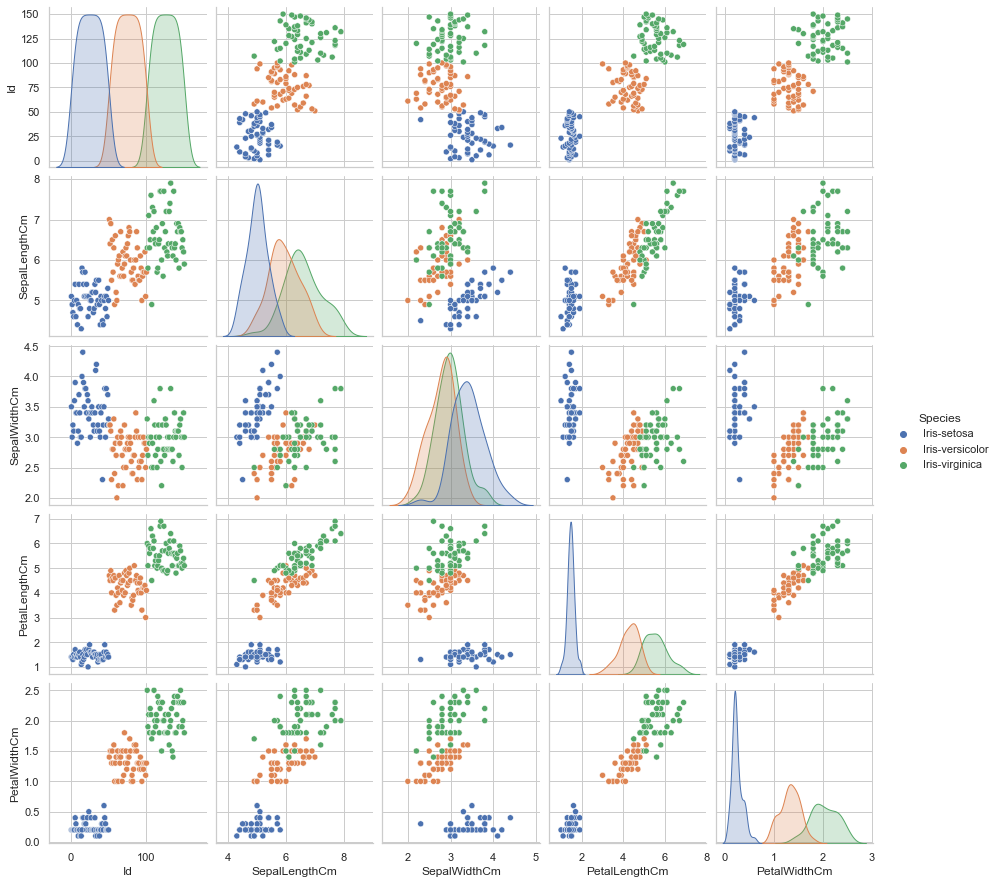

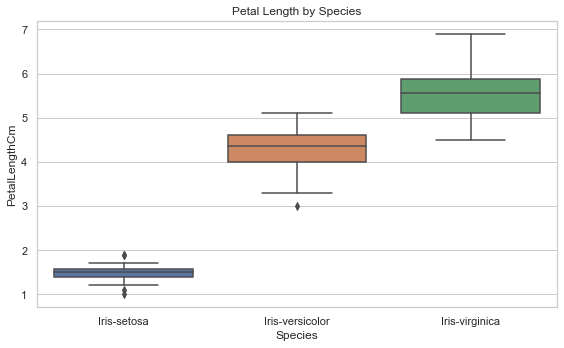

In [9]:
# 2.Perform exploratory data analysis on the IRIS dataset.
# Visualize the relationship between the class label (Species) and predictor 
# variables using appropriate plots. Comment briefly on the observed class separation. 

# Pairplot to visualize relationships and class separation
sns.pairplot(df, hue="Species")
plt.savefig("iris_pairplot.png", dpi=200)
plt.show()

# Boxplot comparing petal length across species
plt.figure(figsize=(8, 5))
sns.boxplot(x="Species", y="PetalLengthCm", data=df)
plt.title("Petal Length by Species")
plt.tight_layout()
plt.savefig("iris_petal_length_boxplot.png", dpi=200)
plt.show()

In [25]:
# 3.	Use the IRIS dataset to build a Logistic Regression classifier using Scikit-learn 
# to predict the class label Species. Divide the dataset into 70% training data and 30% 
# testing data using train_test_split(). Train the model and predict the Species for the test dataset. 
X = df.drop(columns=["Id", "Species"]).copy()
y = df["Species"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)

print("\nTRAINING SET SHAPE:", X_train.shape)
print("TEST SET SHAPE:", X_test.shape)

prediction_table = pd.DataFrame({
    "Actual class": y_test.to_numpy(),
    "Predicted class": y_pred,
    "Probability (Setosa)": y_probability[:, 0],
    "Probability (Versicolor)": y_probability[:, 1],
    "Probability (Virginica)": y_probability[:, 2],
})
print("\nFIRST 15 TEST PREDICTIONS")
print(prediction_table.head(15).round(4).to_string(index=False))


TRAINING SET SHAPE: (105, 4)
TEST SET SHAPE: (45, 4)

FIRST 15 TEST PREDICTIONS
   Actual class Predicted class  Probability (Setosa)  Probability (Versicolor)  Probability (Virginica)
 Iris-virginica  Iris-virginica                0.0000                    0.1013                   0.8986
Iris-versicolor Iris-versicolor                0.0141                    0.7893                   0.1966
 Iris-virginica Iris-versicolor                0.0036                    0.6199                   0.3766
Iris-versicolor Iris-versicolor                0.0217                    0.6297                   0.3485
 Iris-virginica  Iris-virginica                0.0051                    0.3853                   0.6096
 Iris-virginica  Iris-virginica                0.0000                    0.0226                   0.9774
Iris-versicolor Iris-versicolor                0.0158                    0.9144                   0.0698
Iris-versicolor Iris-versicolor                0.0339                    0.9382


Accuracy: 0.9111

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.82      0.93      0.87        15
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45



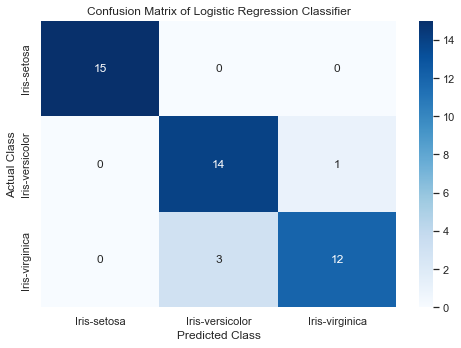

In [11]:
# 4.	Evaluate the performance of the Logistic Regression classifier 
# using appropriate classification metrics. Generate and visualize the confusion matrix and report:
# •	Accuracy 
# •	Precision 
# •	Recall 
# •	F1-score 
# Comment on the performance of the classifier.


accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)

print(f"\nAccuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_,
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix of Logistic Regression Classifier")
plt.tight_layout()
plt.savefig("iris_confusion_matrix.png", dpi=200)
plt.show()


KNN ACCURACY FOR k FROM 2 TO 20
 k  Accuracy
 2  0.888889
 3  0.911111
 4  0.911111
 5  0.911111
 6  0.911111
 7  0.933333
 8  0.911111
 9  0.955556
10  0.933333
11  0.955556
12  0.933333
13  0.933333
14  0.955556
15  0.933333
16  0.911111
17  0.911111
18  0.911111
19  0.911111
20  0.888889


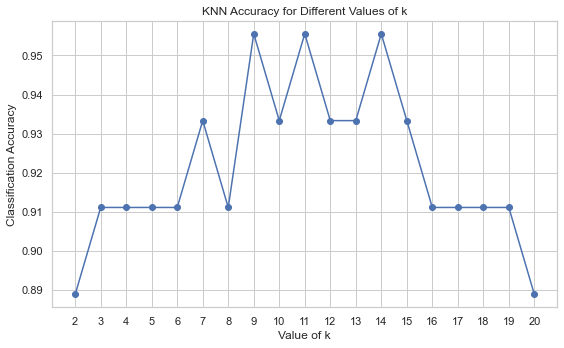

In [27]:
# 5. 5.	Build a K-Nearest Neighbours (KNN) classifier using KNeighborsClassifier from Scikit-learn 
# to predict Species. Use a 70:30 training-test split and train separate KNN models for values 
# of k from 2 to 20. Record the classification accuracy obtained for each value of k. 

k_values = range(2, 21)
accuracies = []

for k in k_values:
  knn_model = Pipeline(steps=[
      ("scaler", StandardScaler()),
      ("classifier", KNeighborsClassifier(n_neighbors=k)),
  ])
  knn_model.fit(X_train, y_train)
  y_pred_knn = knn_model.predict(X_test)
  acc = accuracy_score(y_test, y_pred_knn)
  accuracies.append(acc)

knn_results = pd.DataFrame({"k": list(k_values), "Accuracy": accuracies})

print("\nKNN ACCURACY FOR k FROM 2 TO 20")
print(knn_results.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker="o", linestyle="-", color="b")
plt.xlabel("Value of k")
plt.ylabel("Classification Accuracy")
plt.title("KNN Accuracy for Different Values of k")
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.savefig("knn_accuracy_plot.png", dpi=200)
plt.show()


Final KNN Accuracy (k=9): 0.9556

KNN Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.88      1.00      0.94        15
 Iris-virginica       1.00      0.87      0.93        15

       accuracy                           0.96        45
      macro avg       0.96      0.96      0.96        45
   weighted avg       0.96      0.96      0.96        45



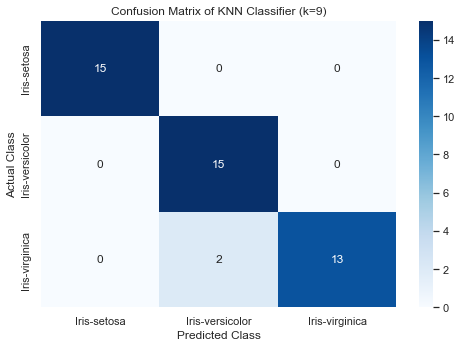

In [29]:
# 6.	Plot k value versus classification accuracy for k = 2 to 20. From the results, 
# identify the best value of k and use it to generate the confusion matrix and classification 
# metrics for the final KNN model. 

best_k = 9

final_knn_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=best_k)),
])

final_knn_model.fit(X_train, y_train)
y_pred_knn = final_knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"\nFinal KNN Accuracy (k={best_k}): {knn_accuracy:.4f}")
print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix for Final KNN
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=final_knn_model.classes_)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=final_knn_model.classes_,
    yticklabels=final_knn_model.classes_,
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title(f"Confusion Matrix of KNN Classifier (k={best_k})")
plt.tight_layout()
plt.savefig("knn_confusion_matrix.png", dpi=200)
plt.show()

In [30]:
# 7.	Compare the performance of Logistic Regression and K-Nearest Neighbours using a suitable table containing:
# •	Accuracy 
# •	Precision 
# •	Recall 
# •	F1-score 
# Based on the experimental results, determine which classifier performs better 
# for the IRIS dataset and justify your conclusion.

lr_prec, lr_rec, lr_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="weighted"
)
knn_prec, knn_rec, knn_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_knn, average="weighted"
)

comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", f"KNN (k={best_k})"],
    "Accuracy": [accuracy, knn_accuracy],
    "Precision": [lr_prec, knn_prec],
    "Recall": [lr_rec, knn_rec],
    "F1-score": [lr_f1, knn_f1],
})

print("\nMODEL PERFORMANCE COMPARISON")
print(comparison_table.round(4).to_string(index=False))


MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall  F1-score
Logistic Regression    0.9111     0.9155  0.9111    0.9107
          KNN (k=9)    0.9556     0.9608  0.9556    0.9554
